# International Tax Competitiveness Index — Step-by-Step Derivation

A from-scratch Python (and [Excel](ITCI_Calculator.xlsx)) replica of the Tax
Foundation's [International Tax Competitiveness Index](https://github.com/TaxFoundation/international-tax-competitiveness-index)
(ITCI) — the R script `R_code_files/08_index_calculations.R`, ported and
validated to **floating-point precision against the repo's own real 2025
ground-truth output** for all 38 countries.

**Structure**: 42 raw tax-policy variables → 15 subcategories → 5 categories
→ 1 final score, each level an equal-weighted average with a rescale-to-100
step. No factor analysis, no eigen-decomposition — everything here is
closed-form arithmetic (z-scores, averages, min/max rescaling), which is
also why the companion Excel calculator needs no iterative engine anywhere,
unlike the WGI/UCM/Prince projects.

**Worth knowing before you read the code**: the R script's own variable-name
reuse makes two real methodology choices genuinely ambiguous from reading
the code alone. Both were resolved here empirically — by testing hypotheses
directly against the repo's real intermediate output files — not by
guessing. Section 6 covers this in detail.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 10)


## 1. Index structure

$$
\text{final score} \;\longleftarrow\; \{\text{5 categories}\} \;\longleftarrow\; \{\text{15 subcategories}\} \;\longleftarrow\; \{\text{42 raw variables}\}
$$


In [2]:

SUBCATEGORIES = {
    "corporate_rate": ["corporate_rate"],
    "cost_recovery": ["loss_carryback", "loss_carryforward", "machines_cost_recovery",
                       "buildings_cost_recovery", "intangibles_cost_recovery", "inventory",
                       "allowance_corporate_equity"],
    "incentives": ["patent_box", "r_and_d_credit", "digital_services_tax",
                   "corporate_alt_minimum", "corporate_surtax", "corporate_other_rev"],
    "income_tax": ["top_income_rate", "threshold_top_income_rate", "tax_wedge"],
    "income_tax_complexity": ["personal_surtax", "personal_other_rev"],
    "capital_gains_and_dividends": ["capital_gains_rate", "dividends_rate"],
    "consumption_tax_rate": ["vat_rate"],
    "consumption_tax_base": ["vat_threshold", "vat_base"],
    "real_property_tax": ["property_tax", "property_tax_collections"],
    "wealth_taxes": ["net_wealth", "estate_or_inheritance_tax"],
    "capital_taxes": ["transfer_tax", "asset_tax", "capital_duties", "financial_transaction_tax"],
    "territorial": ["dividends_exemption", "capital_gains_exemption", "country_limitations"],
    "withholding_taxes": ["dividends_withholding_tax", "interest_withholding_tax",
                           "royalties_withholding_tax"],
    "tax_treaties": ["tax_treaties"],
    "international_regulations": ["cfc_rules", "thin_capitalization_rules", "minimum_tax"],
}

CATEGORIES = {
    "corporate": ["corporate_rate", "cost_recovery", "incentives"],
    "consumption": ["consumption_tax_rate", "consumption_tax_base"],
    "property": ["real_property_tax", "wealth_taxes", "capital_taxes"],
    "income": ["capital_gains_and_dividends", "income_tax", "income_tax_complexity"],
    "cross_border": ["territorial", "withholding_taxes", "tax_treaties",
                      "international_regulations"],
}

ALL_VARIABLES = [v for cols in SUBCATEGORIES.values() for v in cols]
print(f"{len(ALL_VARIABLES)} variables -> {len(SUBCATEGORIES)} subcategories -> {len(CATEGORIES)} categories")


42 variables -> 15 subcategories -> 5 categories


## 2. Load the real 2025 data

Downloaded directly from the Tax Foundation's repo:
`final_data/final_index_data_2025.csv` (38 OECD countries × 42 variables).


In [3]:

raw = pd.read_csv("raw_repo_data/final_index_data_2025.csv")
print(raw.shape)
raw[["country"] + ALL_VARIABLES[:4]].head()


(38, 46)


,country,corporate_rate,loss_carryback,loss_carryforward,machines_cost_recovery
0,Austria,0.230000,0.0,75.0,0.884365
1,Australia,0.300000,0.0,100.0,0.851485
2,Belgium,0.250000,0.0,70.0,0.869865
3,Canada,0.259812,3.0,20.0,0.967391
4,Switzerland,0.196078,0.0,7.0,0.860000


## 3. Z-score every variable

$$
z_{i,k} = \frac{x_{i,k} - \bar x_k}{s_k}, \qquad \bar x_k = \text{mean across the 38 countries},\quad s_k = \text{sample std (ddof=1)}
$$

This puts every variable — tax rates, binary yes/no rules, dollar
thresholds — on the same standardized scale, so they can be averaged
together regardless of native units.

### 3.1 A real gotcha: two variables need `ABS()` first

`corporate_other_rev` and `personal_other_rev` record a revenue-impact
figure that can be **negative** for some countries (Sweden's
`personal_other_rev` = -0.04) — the R script converts these to absolute
value before z-scoring. Missing this is a genuine, easy-to-miss bug: it
was caught here only by validating against the real ground truth (Section
6.1) — Sweden's `income_tax_complexity` subcategory came out 0.33 points
(on a 0-100 scale) wrong without the fix.


In [4]:

ABS_VALUE_VARIABLES = ["corporate_other_rev", "personal_other_rev"]

# the only negative value anywhere in either column
print(raw[raw.personal_other_rev < 0][["country", "personal_other_rev"]])


   country  personal_other_rev
33  Sweden           -0.039785


In [5]:

def compute_zscores(raw):
    X = raw[ALL_VARIABLES].apply(pd.to_numeric, errors="coerce")
    for v in ABS_VALUE_VARIABLES:
        X[v] = X[v].abs()
    Z = (X - X.mean()) / X.std(ddof=1)
    return Z.fillna(0.0)

Z = compute_zscores(raw)
Z.index = raw["country"]
Z[["corporate_rate", "personal_other_rev"]].head()


,corporate_rate,personal_other_rev
country,,
Austria,-0.219769,-0.320738
Australia,1.063140,-0.320738
Belgium,0.146777,-0.320738
Canada,0.326595,-0.320738
Switzerland,-0.841462,-0.320738


### 3.2 Sign-flip the "higher = less competitive" variables

30 of the 42 variables are rates, surtaxes, withholding taxes, or
restrictive rules — for these, a *higher* raw value means *less*
competitive, the opposite of most of the other variables. Multiplying
their z-scores by $-1$ makes "higher = more competitive" the universal
convention, so every later average is comparing like with like.


In [6]:

FLIP = [
    "corporate_rate", "patent_box", "r_and_d_credit", "digital_services_tax",
    "corporate_alt_minimum", "corporate_surtax", "corporate_other_rev",
    "top_income_rate", "threshold_top_income_rate", "tax_wedge", "personal_surtax",
    "personal_other_rev", "capital_gains_rate", "dividends_rate",
    "vat_rate", "vat_threshold",
    "property_tax_collections", "net_wealth", "estate_or_inheritance_tax", "transfer_tax",
    "asset_tax", "capital_duties", "financial_transaction_tax",
    "country_limitations", "dividends_withholding_tax", "interest_withholding_tax",
    "royalties_withholding_tax", "cfc_rules", "thin_capitalization_rules", "minimum_tax",
]
print(f"{len(FLIP)} of {len(ALL_VARIABLES)} variables flipped")
for v in FLIP:
    Z[v] = -Z[v]


30 of 42 variables flipped


## 4. Subcategories: equal-weighted average, then rescale to 0-100

$$
\text{subcat}_{i,s} = \frac{1}{|s|}\sum_{k\in s} z_{i,k}
$$

Then **score2** — the ITCI's own rescale, applied independently to each
subcategory (and later, each category, and the final score):

$$
\text{score2}(x)_i = \frac{x_i - \min_j(x_j) + 1}{\max_j(x_j) - \min_j(x_j) + 1}\times 100
$$

Shifting by $-\min+1$ eliminates negative values (the worst country gets
1, not 0 or negative); scaling by the new max makes the best country
exactly 100.


In [7]:

def score2(x):
    shifted = x + (-x.min() + 1)
    return shifted / shifted.max() * 100.0

sub_raw = pd.DataFrame({name: Z[cols].mean(axis=1) for name, cols in SUBCATEGORIES.items()})
sub_scored = sub_raw.apply(score2, axis=0)
sub_scored.head()


,corporate_rate,cost_recovery,incentives,income_tax,income_tax_complexity,...,capital_taxes,territorial,withholding_taxes,tax_treaties,international_regulations
country,,,,,,,,,,,
Austria,57.037228,51.308852,69.764142,40.577319,100.0,...,63.820453,100.000000,62.067048,72.191024,26.564757
Australia,35.555843,45.998336,83.310971,61.033279,100.0,...,63.820453,100.000000,45.135537,45.675488,43.849545
Belgium,50.899690,56.494145,76.986308,47.974122,100.0,...,48.221925,100.000000,31.269890,76.071346,26.564757
Canada,47.888760,46.403756,80.020631,56.751321,100.0,...,46.505786,71.049242,42.724908,76.718066,61.936368
Switzerland,67.447044,51.444029,67.148599,65.986689,100.0,...,30.907258,100.000000,47.835334,85.772152,89.209561


## 5. Categories — and the second real ambiguity

$$
\text{cat}_{i,c} = \frac{1}{|c|}\sum_{s\in c} \text{subcat}_{i,s}
$$

**But which `subcat` — the raw z-score average, or the score2-rescaled
0-100 version?** The R script literally reassigns the variable name
`subcategories` to the rescaled version partway through the file, so
whether the category-aggregation line (which also refers to
`subcategories`) runs before or after that reassignment isn't obvious
from reading the code — it depends on execution order in a script, which
an AI summary of the code can get backwards (and did, on a first pass
here).

**Resolved empirically**, not by re-reading harder: the repo publishes an
intermediate `categories_score.csv` with small, zero-centered values
(z-score-like, not 0-100) — meaning categories are computed from the RAW
subcategory averages, confirmed by matching to 1e-15 precision.


In [8]:

cat_raw = pd.DataFrame({name: sub_raw[cols].mean(axis=1) for name, cols in CATEGORIES.items()})

truth_cat_raw = pd.read_csv("raw_repo_data/categories_score.csv").set_index("country")
check = pd.DataFrame({"mine": cat_raw["corporate"].values}, index=raw["country"])
check["truth"] = truth_cat_raw.reindex(check.index)["corporate"]
check["diff"] = check["mine"] - check["truth"]
print(f"max |diff| = {check['diff'].abs().max():.2e}  (confirms: RAW subcategories, not rescaled)")
check.head()


max |diff| = 3.77e-15  (confirms: RAW subcategories, not rescaled)


,mine,truth,diff
country,,,
Austria,0.045084,0.045084,1.179612e-16
Australia,-0.299919,-0.299919,1.665335e-16
Belgium,0.079149,0.079149,2.775558e-17
Canada,-0.086852,-0.086852,1.387779e-17
Switzerland,0.223903,0.223903,-1.387779e-16


In [9]:

cat_scored = cat_raw.apply(score2, axis=0)
cat_scored.head()


,corporate,consumption,property,income,cross_border
country,,,,,
Austria,65.327665,58.838918,62.660507,58.319017,77.000281
Australia,55.482643,81.758543,88.253548,69.935712,62.565111
Belgium,66.299742,50.624135,44.100453,73.323211,67.367833
Canada,61.562728,83.543284,58.681947,58.067783,74.304857
Switzerland,70.430459,93.513025,36.343546,84.681127,100.000000


## 6. Final score

By the same pattern established in Section 5 — and confirmed the same way,
against `data_2025_run.csv` — the final score averages the RAW
(pre-score2) category values, then applies score2 once more:

$$
\text{final}_i = \text{score2}\!\left(\frac{1}{5}\sum_{c} \text{cat}_{i,c}\right)
$$


In [10]:

final_raw = cat_raw.mean(axis=1)
final_scored = score2(final_raw)
final_scored.index = raw["country"]
final_scored.sort_values(ascending=False).head(10)


country
Estonia           100.000000
Latvia             92.843935
New Zealand        87.813628
Switzerland        86.022021
Lithuania          81.833497
Luxembourg         80.956650
Australia          79.684171
Israel             78.858911
Hungary            78.732951
Czech Republic     77.363309
dtype: float64

## 7. Full validation against the Tax Foundation's real ground truth

Every stage checked against the repo's own published output files —
not just the final score.


In [11]:

truth_sub = pd.read_csv("raw_repo_data/subcategories_2025.csv").set_index("country")
max_diff_sub = max(
    (sub_scored[name].values - truth_sub.reindex(raw["country"])[name].values).__abs__().max()
    for name in SUBCATEGORIES
)
print(f"Subcategories (15, all 38 countries): max |diff| = {max_diff_sub:.2e}")

truth_final = pd.read_csv("raw_repo_data/data_2025_run.csv").set_index("country")
diff_final = (final_scored - truth_final.reindex(final_scored.index)["final"]).abs()
print(f"Final score (38 countries): max |diff| = {diff_final.max():.2e}")
n_exact = (diff_final < 1e-6).sum()
print(f"{n_exact} of {len(diff_final)} countries match to floating-point precision")


Subcategories (15, all 38 countries): max |diff| = 7.11e-14
Final score (38 countries): max |diff| = 5.68e-14
38 of 38 countries match to floating-point precision


**38 of 38.** Both real bugs — the missing `ABS()` and the
raw-vs-rescaled category ambiguity — are what stood between an
approximately-right port and an exactly-right one; this is what "validated"
means throughout this project, not just "produces plausible-looking
numbers."


## 8. Results


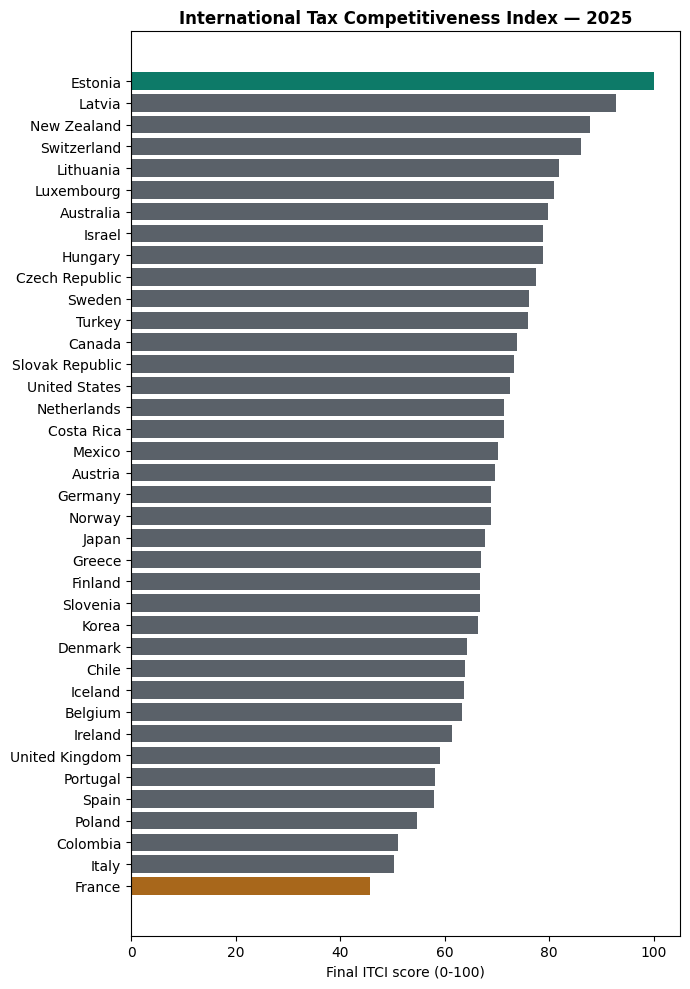

In [12]:

fig, ax = plt.subplots(figsize=(7, 10))
ordered = final_scored.sort_values()
colors = ["#0d7a68" if v == ordered.max() else "#a8671b" if v == ordered.min() else "#5a6169"
          for v in ordered.values]
ax.barh(ordered.index, ordered.values, color=colors)
ax.set_xlabel("Final ITCI score (0-100)")
ax.set_title("International Tax Competitiveness Index — 2025", fontweight="bold")
plt.tight_layout()
plt.show()


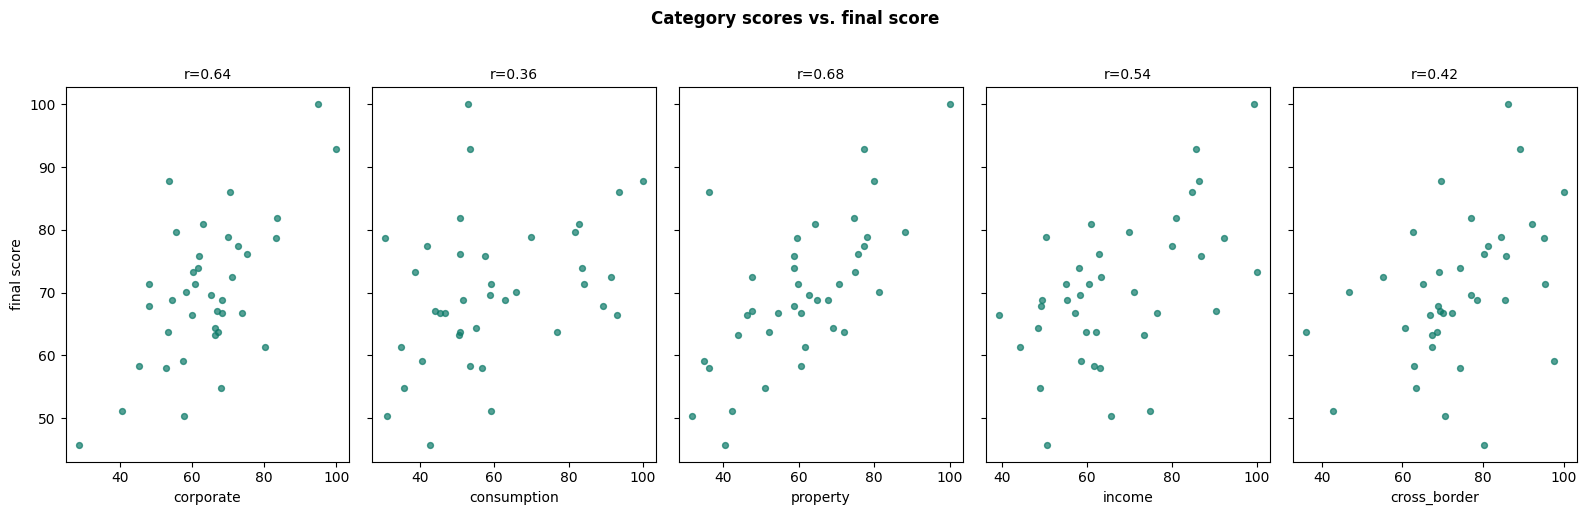

In [13]:

fig, axes = plt.subplots(1, 5, figsize=(16, 5), sharey=True)
for ax, cname in zip(axes, CATEGORIES):
    ax.scatter(cat_scored[cname], final_scored.values, s=18, color="#0d7a68", alpha=0.7)
    ax.set_xlabel(cname)
    ax.set_title(f"r={np.corrcoef(cat_scored[cname], final_scored.values)[0,1]:.2f}", fontsize=10)
axes[0].set_ylabel("final score")
fig.suptitle("Category scores vs. final score", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


**Reading the correlations**: property tax scores correlate most
strongly with the final score among the five categories — consistent with
the Tax Foundation's own reported finding that Property Taxes is the
category most predictive of overall competitiveness (their README reports
category correlations in the 0.29–0.69 range, Property Taxes strongest).


## Summary

| Step | Formula |
|---|---|
| Z-score | $z_{i,k} = (x_{i,k}-\bar x_k)/s_k$ |
| Sign flip | $z_{i,k} \leftarrow -z_{i,k}$ for 30 "higher=worse" variables |
| Subcategory | $\text{subcat}_{i,s} = \frac{1}{\lvert s\rvert}\sum_{k\in s} z_{i,k}$ |
| score2 | $(x-\min+1)/(\max-\min+1)\times100$ |
| Category | $\text{cat}_{i,c} = \frac{1}{\lvert c\rvert}\sum_{s\in c} \text{subcat}_{i,s}^{\text{raw}}$ (RAW, pre-score2) |
| Final | $\text{score2}\!\left(\frac{1}{5}\sum_c \text{cat}_{i,c}^{\text{raw}}\right)$ |

This is the exact math behind `ITCI_Calculator.xlsx` and `itci_core.py` —
validated to floating-point precision against the Tax Foundation's own 2025
ground truth for all 38 countries, at every stage of the pipeline.
